<a href="https://colab.research.google.com/github/websterj3-sketch/QLC140Spring26/blob/main/Exercise3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3
- Import a SSH (sea surface height) file and plot the SSH on a map
- Export figure and print for class

In [10]:
# Import packages: pandas, numpy, matplotlib, seaborn, cartopy.crs, cartopy.feature, and scipy.interpolate
!pip install cartopy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata

In [6]:
# Import ssh_practicedata.csv as a pandas dataframe
df = pd.read_csv('/content/ssh_practicedata.csv')
display(df.head())

,lat,lon,ssh
0,20,-80,0.12
1,20,-75,0.15
2,20,-70,0.18
3,20,-65,0.22
4,20,-60,0.25


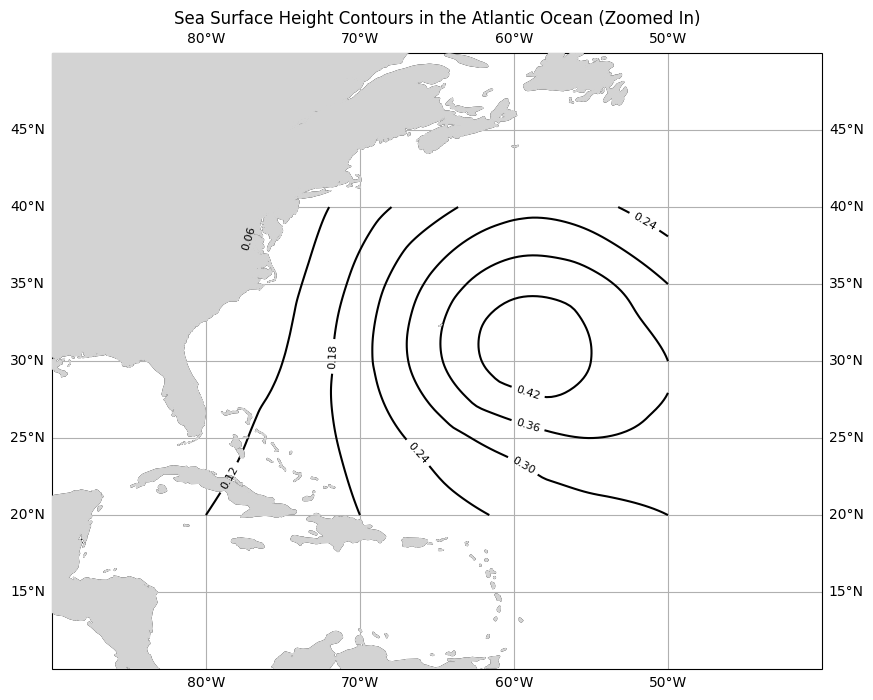

In [17]:
# Plot the data on to a map of the Atlantic Ocean with continents/land indicated on the map as well.

# Extract latitude, longitude, and SSH values
lat = df['lat']
lon = df['lon']
ssh = df['ssh']

# Create a regular grid for interpolation
lon_grid = np.linspace(lon.min(), lon.max(), 100)
lat_grid = np.linspace(lat.min(), lat.max(), 100)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# Interpolate the SSH data onto the new grid
ssh_grid = griddata((lon, lat), ssh, (lon_mesh, lat_mesh), method='cubic')

# Create a figure and an axes object with a Plate Carree projection
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Set the extent of the map to focus on the plotted data with an additional 10-degree buffer to zoom in
ax.set_extent([
    lon.min() - 10, lon.max() + 10,
    lat.min() - 10, lat.max() + 10
], crs=ccrs.PlateCarree())

# Add coastline and borders first
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Plot the SSH data as contour lines (zorder=2)
# Use 'colors' to specify a single color for lines and avoid shading
contour = ax.contour(
    lon_mesh, lat_mesh, ssh_grid, colors='black', linestyles='-', transform=ccrs.PlateCarree(), zorder=2
)

# Add contour labels
plt.clabel(contour, inline=True, fontsize=8)

# Add land feature on top of the contour plot with a higher zorder (e.g., zorder=3)
ax.add_feature(cfeature.LAND, color='lightgray', zorder=3)

# Add a title
ax.set_title('Sea Surface Height Contours in the Atlantic Ocean (Zoomed In)')

# Export figure
plt.savefig('ssh_atlantic_contour_zoomed_in.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()